In [1]:
#Import needed libraries
import os
import numpy as np
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image
from sklearn.preprocessing import StandardScaler, LabelEncoder
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
DATA_DIR = r"Downloads/Data 2"
IMG_HEIGHT, IMG_WIDTH = 224, 224
CLASS_NAMES = ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']



In [7]:
def load_images_from_folder(folder_path):
    """Load all images from a folder and return as array with labels"""
    images = []
    labels = []
    #checking that path exists or not
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} does not exist!")
        return np.array([]), np.array([])
    
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(folder_path, class_name)
        #Where the class path is found
        if not os.path.exists(class_path):
            print(f"Warning: {class_path} not found")
            continue
        
        file_count = 0
        for img_file in tqdm(os.listdir(class_path), desc=f"Loading {class_name}"):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, img_file)
                
                try:
                    # Load and preprocess image
                    img = load_img(img_path, color_mode='grayscale', target_size=(IMG_HEIGHT, IMG_WIDTH))
                    img_array = img_to_array(img) / 255.0  # Normalize to [0,1]
                    
                    images.append(img_array)
                    labels.append(class_idx)
                    file_count += 1
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
        
        print(f"  Loaded {file_count} images from {class_name}")
    
    if len(images) == 0:
        print(f"ERROR: No images found in {folder_path}")
        return np.array([]), np.array([])
    
    return np.array(images), np.array(labels)

In [8]:
def augment_training_data(X_train, y_train):
    augmenter = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomShear(x_factor = 0.1, y_factor = 0.1, seed = 42),
        tf.keras.layers.RandomBrightness(factor = 0.1, value_range = (0,1))
    ])

    X_aug = []
    y_aug = []

    for i in range(len(X_train)):
        img = X_train[i]

        img = tf.expand_dims(img, axis=0)  # (1, H, W, C)
        aug_img = augmenter(img, training=True)

        aug_img = tf.squeeze(aug_img, axis=0)  # back to (H, W, C)

        X_aug.append(aug_img.numpy())
        y_aug.append(y_train[i])
    num_samples = 5
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        axes[i].imshow(X_aug[i], cmap = 'gray')
        axes[i].axis('off')
    title = 'Augmented'
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    X_train_new = np.concatenate([X_train, np.array(X_aug)], axis=0)
    y_train_new = np.concatenate([y_train, np.array(y_aug)], axis=0)

    return X_train_new, y_train_new

In [9]:
def prepare_for_logistic_regression(X_train, X_val, X_test):
    """Flatten and standardize images for logistic regression"""
  
    if len(X_train) == 0:
        print("ERROR: Training set is empty!")
        return None, None, None, None
    
   # Flatten images
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    

    if len(X_val) > 0:
        X_val_flat = X_val.reshape(X_val.shape[0], -1)
    else:
        X_val_flat = np.array([])
        print("Warning: Validation set is empty, using training data for validation")
    
    if len(X_test) > 0:
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
    else:
        X_test_flat = np.array([])
        print("Test set is empty")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    
    if len(X_val_flat) > 0:
        X_val_scaled = scaler.transform(X_val_flat)
    else:
        X_val_scaled = np.array([])
    
    if len(X_test_flat) > 0:
        X_test_scaled = scaler.transform(X_test_flat)
    else:
        X_test_scaled = np.array([])
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

In [10]:
def prepare_for_cnn(X_train, X_val, X_test):

    if len(X_train) > 0:
        X_train_cnn = X_train[..., np.newaxis] 
    else:
        X_train_cnn = np.array([])
    
    if len(X_val) > 0:
        X_val_cnn = X_val[..., np.newaxis]
    else:
        X_val_cnn = np.array([])
    
    if len(X_test) > 0:
        X_test_cnn = X_test[..., np.newaxis]
    else:
        X_test_cnn = np.array([])
    
    return X_train_cnn, X_val_cnn, X_test_cnn

In [11]:
def visualize_samples(X, y,title="Sample Images"):
    """Display random samples to verify preprocessing"""
    if len(X) == 0:
        print("No images to visualize")
        return
    
    num_samples = min(5, len(X))
    fig, axes = plt.subplots(1, num_samples, figsize=(25, 3))
    

    if num_samples == 1:
        axes = [axes]
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(X))
        img = X[idx].squeeze()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(CLASS_NAMES[y[idx]])
        axes[i].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [12]:
os.getcwd()

'/Users/abelmetek'

LUNG CT PREPROCESSING PIPELINE

[1/5] Loading train/val/test splits...

Looking for data in:
  Train: Downloads/Data 2/train
  Val: Downloads/Data 2/valid
  Test: Downloads/Data 2/test



Loading adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 100%|█| 195/195 [00:00<00:00


  Loaded 195 images from adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib


Loading large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 100%|█| 115/115 [00:00<00


  Loaded 115 images from large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa


...

  Loaded 51 images from large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa


Loading normal: 100%|██████████████████████████| 54/54 [00:00<00:00, 111.09it/s]


  Loaded 54 images from normal


Loading squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 100%|█| 90/90 [00:00<0


  Loaded 90 images from squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa
[[[[0.        ]
   [0.        ]
   [0.00392157]
   ...
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.00392157]
   [0.        ]
   [0.        ]
   ...
   [0.00392157]
   [0.00392157]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   ...
   [0.        ]
   [0.00392157]
   [0.        ]]

  ...

  [[0.        ]
   [0.        ]
   [0.        ]
   ...
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   ...
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   ...
   [0.        ]
   [0.        ]
   [0.        ]]]


 [[[0.        ]
   [0.        ]
   [0.        ]
   ...
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   ...
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   ...
   [0.        ]
   [0. 

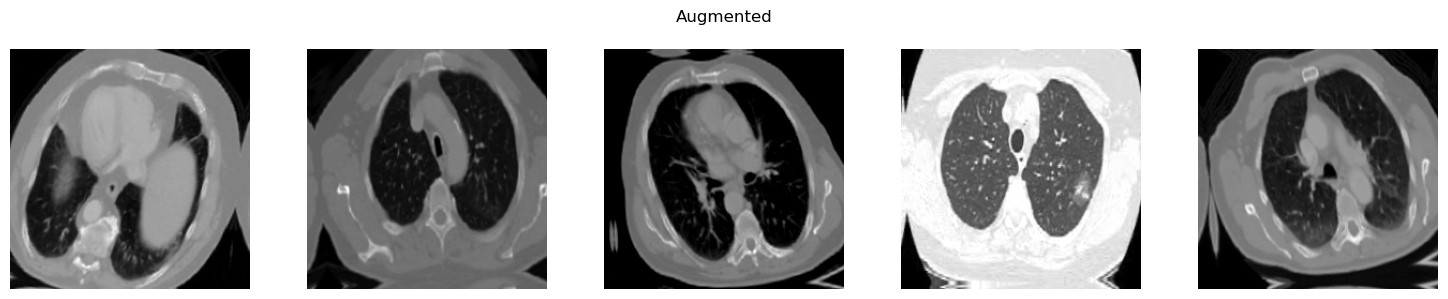

✓ Augmented train size: 1226

✓ Train: 1226 images
✓ Validation: 72 images
✓ Test: 315 images
✓ Image shape: (224, 224, 1)

[2/5] Class distribution:
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: Train=390, Val=23, Test=120
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: Train=230, Val=21, Test=51
  normal: Train=296, Val=13, Test=54
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: Train=310, Val=15, Test=90

[3/5] Preparing for CNN models...
  Shape ready: (1226, 224, 224, 1, 1)

[4/5] Preparing for Logistic Regression...
  Shape ready: (1226, 50176)

[5/5] Visualizing sample images...


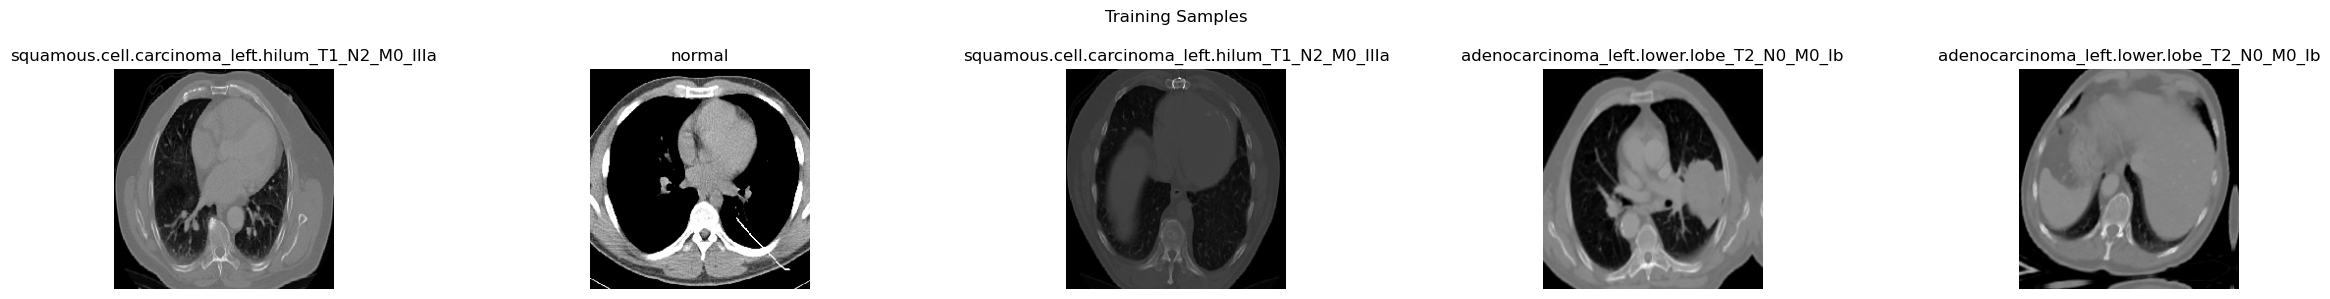


Saving preprocessed data...
✓ Saved to 'lung_ct_preprocessed_cnn.npz' and 'lung_ct_preprocessed_lr.npz'

PREPROCESSING COMPLETE!


In [13]:




# MAIN PREPROCESSING PIPELINE

def main():
    print("=" * 60)
    print("LUNG CT PREPROCESSING PIPELINE")
    print("=" * 60)
    
    print("\n[1/5] Loading train/val/test splits...")
    
    train_path = os.path.join(DATA_DIR, 'train')
    val_path = os.path.join(DATA_DIR, 'valid')
    test_path = os.path.join(DATA_DIR, 'test')
    
    print(f"\nLooking for data in:")
    print(f"  Train: {train_path}")
    print(f"  Val: {val_path}")
    print(f"  Test: {test_path}\n")
    
    X_train, y_train = load_images_from_folder(train_path)
    X_val, y_val = load_images_from_folder(val_path)
    X_test, y_test = load_images_from_folder(test_path)
    print(X_train)
    print(y_test)
    print("\nApplying augmentation to training set...")
    X_train, y_train = augment_training_data(X_train, y_train)

    print(f"✓ Augmented train size: {len(X_train)}")
    
    print(f"\n✓ Train: {len(X_train)} images")
    print(f"✓ Validation: {len(X_val)} images")
    print(f"✓ Test: {len(X_test)} images")
    
    if len(X_train) > 0 and len(X_train[0].shape) == 3:
        print(f"✓ Image shape: {X_train[0].shape}")
    

    print("\n[2/5] Class distribution:")
    for class_idx, class_name in enumerate(CLASS_NAMES):
        train_count = np.sum(y_train == class_idx) if len(y_train) > 0 else 0
        val_count = np.sum(y_val == class_idx) if len(y_val) > 0 else 0
        test_count = np.sum(y_test == class_idx) if len(y_test) > 0 else 0
        total = train_count + val_count + test_count
        if total > 0:
            print(f"  {class_name}: Train={train_count}, Val={val_count}, Test={test_count}")
    
    # Step 3: Prepare for CNN
    print("\n[3/5] Preparing for CNN models...")
    X_train_cnn, X_val_cnn, X_test_cnn = prepare_for_cnn(X_train, X_val, X_test)
    if len(X_train_cnn) > 0:
        print(f"  Shape ready: {X_train_cnn.shape}")
    
    # Step 4: Prepare for Logistic Regression
    print("\n[4/5] Preparing for Logistic Regression...")
    X_train_lr, X_val_lr, X_test_lr, scaler = prepare_for_logistic_regression(X_train, X_val, X_test)
    if X_train_lr is not None and len(X_train_lr) > 0:
        print(f"  Shape ready: {X_train_lr.shape}")
    
    # Step 5: Visualize samples
    print("\n[5/5] Visualizing sample images...")
    if len(X_train) > 0:
        visualize_samples(X_train, y_train, "Training Samples")
    else:
        print("No training images to visualize")
    
    # Save preprocessed data 
    if len(X_train) > 0:
        print("\nSaving preprocessed data...")
       
        np.savez('lung_ct_preprocessed_cnn.npz',
                 X_train=X_train_cnn, y_train=y_train,
                 X_val=X_val_cnn, y_val=y_val,
                 X_test=X_test_cnn, y_test=y_test,
                 class_names=CLASS_NAMES)
        
        if X_train_lr is not None:
            np.savez('lung_ct_preprocessed_lr.npz.',
                     X_train=X_train_lr, y_train=y_train,
                     X_val=X_val_lr, y_val=y_val,
                     X_test=X_test_lr, y_test=y_test,
                     class_names=CLASS_NAMES)
        
        print("✓ Saved to 'lung_ct_preprocessed_cnn.npz' and 'lung_ct_preprocessed_lr.npz'")
    else:
        print("\n❌ ERROR: No training data loaded. Check your folder structure!")
        print("\nExpected folder structure:")
        print("  data/")
        print("    ├── train/")
        print("    │   ├── adenocarcinoma/")
        print("    │   ├── large.cell.carcinoma/")
        print("    │   ├── normal/")
        print("    │   └── squamous.cell.carcinoma/")
        print("    ├── valid/")
        print("    │   └── (same class subfolders)")
        print("    └── test/")
        print("        └── (same class subfolders)")
    
    print("\n" + "=" * 60)
    print("PREPROCESSING COMPLETE!")
    print("=" * 60)
    
    return {
        'X_train_cnn': X_train_cnn, 'X_val_cnn': X_val_cnn, 'X_test_cnn': X_test_cnn,
        'X_train_lr': X_train_lr, 'X_val_lr': X_val_lr, 'X_test_lr': X_test_lr,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'class_names': CLASS_NAMES, 'scaler': scaler
    }

# RUN PIPELINE

if __name__ == "__main__":
    if not os.path.exists(DATA_DIR):
        print(f"ERROR: {DATA_DIR} folder not found!")
        print("\nPlease create this folder structure:")
        print("  data/")
        print("    ├── train/")
        print("    │   ├── adenocarcinoma/")
        print("    │   ├── large.cell.carcinoma/")
        print("    │   ├── normal/")
        print("    │   └── squamous.cell.carcinoma/")
        print("    ├── val/")
        print("    │   └── (same class subfolders)")
        print("    └── test/")
        print("        └── (same class subfolders)")
    else:
        data = main()

In [39]:
print("LUNG CT CLASSIFICATION - MODEL TRAINING & EVALUATION")

print("\n[1/5] Loading preprocessed data...")
lr_data = np.load(r"lung_ct_preprocessed_cnn.npz")
cnn_data = np.load(r"lung_ct_preprocessed_lr.npz..npz")
print(cnn_data)
X_train_lr_orig = lr_data['X_train']
X_val_lr_orig = lr_data['X_val']
X_test_lr_orig = lr_data['X_test']

y_train_orig = lr_data['y_train']
y_val_orig = lr_data['y_val']
y_test_orig = lr_data['y_test']


X_train_cnn_orig = cnn_data['X_train']
print(X_val_cnn_orig.shape)
print(len(X_val_cnn_orig))
X_val_cnn_orig = cnn_data['X_val']
X_test_cnn_orig = cnn_data['X_test']
X_train_cnn_orig = X_train_cnn_orig.reshape(len(X_train_cnn_orig),224, 224, 1)
X_val_cnn_orig = X_val_cnn_orig.reshape(len(X_val_cnn_orig),224, 224, 1)
X_test_cnn_orig = X_test_cnn_orig.reshape(len(X_test_cnn_orig),224, 224, 1)

print("\n[2/5] Combining train and test data...")

X_all_lr = np.concatenate([X_train_lr_orig, X_test_lr_orig])
X_all_cnn = np.concatenate([X_train_cnn_orig, X_test_cnn_orig])
y_all = np.concatenate([y_train_orig, y_test_orig])
print(X_all_cnn.shape)
print(f"Total combined images: {len(X_all_lr)}")
print(f"Class distribution: {np.bincount(y_all)}")

# 70% train, 15% val, 15% test

X_temp_lr, X_test_lr, y_temp, y_test = train_test_split(
    X_all_lr, y_all, test_size=0.15, stratify=y_all, random_state=42
)

X_train_lr, X_val_lr, y_train, y_val = train_test_split(
    X_temp_lr, y_temp, test_size=0.176, stratify=y_temp, random_state=42
)

X_temp_cnn, X_test_cnn, _, _ = train_test_split(
    X_all_cnn, y_all, test_size=0.15, stratify=y_all, random_state=42
)
X_train_cnn, X_val_cnn, _, _ = train_test_split(
    X_temp_cnn, y_temp, test_size=0.176, stratify=y_temp, random_state=42
)

class_names = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']

print(f"\n✓ NEW Training set: {len(X_train_lr)} images")
print(f"  Class distribution: {np.bincount(y_train)}")
print(f"✓ NEW Validation set: {len(X_val_lr)} images")
print(f"  Class distribution: {np.bincount(y_val)}")
print(f"✓ NEW Test set: {len(X_test_lr)} images")
print(f"  Class distribution: {np.bincount(y_test)}")
print(f"✓ Classes: {class_names}")

# convert grayscale to RGB
print("\n[3/5] Preparing data for ResNet50 (converting grayscale to RGB)...")
print(X_train_cnn.shape)
X_train_resnet = np.repeat(X_train_cnn.squeeze(-1), 3, axis=-1)
X_val_resnet = np.repeat(X_val_cnn.squeeze(-1), 3, axis=-1)
X_test_resnet = np.repeat(X_test_cnn.squeeze(-1), 3, axis=-1)
print(f"✓ ResNet50 input shape: {X_train_resnet.shape}")

# Convert labels to categorical for CNN and ResNet
y_train_cat = to_categorical(y_train, num_classes=4)
y_val_cat = to_categorical(y_val, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

LUNG CT CLASSIFICATION - MODEL TRAINING & EVALUATION

[1/5] Loading preprocessed data...
NpzFile 'lung_ct_preprocessed_lr.npz..npz' with keys: X_train, y_train, X_val, y_val, X_test...
(72, 224, 224, 1)
72

[2/5] Combining train and test data...
(1541, 224, 224, 1)
Total combined images: 1541
Class distribution: [510 281 350 400]

✓ NEW Training set: 1078 images
  Class distribution: [357 197 244 280]
✓ NEW Validation set: 231 images
  Class distribution: [76 42 53 60]
✓ NEW Test set: 232 images
  Class distribution: [77 42 53 60]
✓ Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']

[3/5] Preparing data for ResNet50 (converting grayscale to RGB)...
(1078, 224, 224, 1)
✓ ResNet50 input shape: (1078, 224, 672)


In [41]:
# 2. EVALUATION FUNCTION

def evaluate_model(y_true, y_pred, y_pred_proba, model_name="Model", dataset_type="Validation"):
    """
    Comprehensive model evaluation with requested metrics
    """
    print(f"\n{'='*60}")
    print(f"{model_name} - {dataset_type} SET RESULTS")
    print(f"{'='*60}")
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    # ROC-AUC 
    try:
        roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
    except:
        roc_auc = None
    
  
    print(f" \n METRICS:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    
    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    print(f"\n PER-CLASS BREAKDOWN:")
    print(f"  {'Class':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*10}")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name:<25} {per_class_precision[i]:>10.4f} {per_class_recall[i]:>10.4f} {per_class_f1[i]:>10.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'roc_auc': roc_auc
    }, cm







In [ ]:
# 3. LOGISTIC REGRESSION (BASELINE)
print(X_train_lr.shape)
X_train_lr = X_train_lr.squeeze()
X_train_lr = X_train_lr.reshape(len(X_train_lr), -1)
X_val_lr =  X_val_lr.squeeze()
X_val_lr = X_val_lr.reshape(len(X_train_lr), -1)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_lr, y_train)

y_val_pred_lr = lr_model.predict(X_val_lr)
y_val_proba_lr = lr_model.predict_proba(X_val_lr)

lr_results, lr_cm = evaluate_model(y_val, y_val_pred_lr, y_val_proba_lr, "Logistic Regression", "Validation")

(1078, 50176)


In [ ]:
# 4. RANDOM FOREST

print("\n[4/5] Training Random Forest...")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_lr, y_train)

y_val_pred_rf = rf_model.predict(X_val_lr)
y_val_proba_rf = rf_model.predict_proba(X_val_lr)

rf_results, rf_cm = evaluate_model(y_val, y_val_pred_rf, y_val_proba_rf, "Random Forest", "Validation")

# 5. SIMPLE CNN

print("\n[5/5] Training Simple CNN...")

simple_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

In [ ]:




simple_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

print("Training Simple CNN...")
simple_cnn.fit(X_train_cnn, y_train_cat,
               validation_data=(X_val_cnn, y_val_cat),
               epochs=40, batch_size=32,
               callbacks=[early_stop, reduce_lr],
               verbose=0)

y_val_pred_cnn = np.argmax(simple_cnn.predict(X_val_cnn, verbose=0), axis=1)
y_val_proba_cnn = simple_cnn.predict(X_val_cnn, verbose=0)

cnn_results, cnn_cm = evaluate_model(y_val, y_val_pred_cnn, y_val_proba_cnn, "Simple CNN", "Validation")

# Test set evaluation for CNN
y_test_pred_cnn = np.argmax(simple_cnn.predict(X_test_cnn, verbose=0), axis=1)
y_test_proba_cnn = simple_cnn.predict(X_test_cnn, verbose=0)
cnn_test_results, cnn_test_cm = evaluate_model(y_test, y_test_pred_cnn, y_test_proba_cnn, "Simple CNN", "TEST SET")

# 6. RESNET50 

print("\n[6/6] Training ResNet50 (Transfer Learning)...")

# pretrained ResNet50 without top layers
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))

# Freeze base model layers
base_model.trainable = False

#  top layers
inputs = Input(shape=(128,128,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

resnet_model = Model(inputs, outputs)

resnet_model.compile(optimizer=Adam(learning_rate=0.0001), 
                     loss='categorical_crossentropy', 
                     metrics=['accuracy'])

print("Training ResNet50 (this may take 10-20 minutes)...")
resnet_history = resnet_model.fit(X_train_resnet, y_train_cat,
                                   validation_data=(X_val_resnet, y_val_cat),
                                   epochs=30, batch_size=16,
                                   callbacks=[early_stop, reduce_lr],
                                   verbose=0)

y_val_pred_resnet = np.argmax(resnet_model.predict(X_val_resnet, verbose=0), axis=1)
y_val_proba_resnet = resnet_model.predict(X_val_resnet, verbose=0)

resnet_results, resnet_cm = evaluate_model(y_val, y_val_pred_resnet, y_val_proba_resnet, "ResNet50", "Validation")

# Test set evaluation for ResNet50
y_test_pred_resnet = np.argmax(resnet_model.predict(X_test_resnet, verbose=0), axis=1)
y_test_proba_resnet = resnet_model.predict(X_test_resnet, verbose=0)
resnet_test_results, resnet_test_cm = evaluate_model(y_test, y_test_pred_resnet, y_test_proba_resnet, "ResNet50", "TEST SET")

In [ ]:
# 7. VISUALIZATIONS

def plot_confusion_matrix(cm, class_names, title):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_training_history(history, title):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_model_comparison(results_dict):
    """Bar chart comparing all models"""
    models = list(results_dict.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(models))
    width = 0.15
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, metric in enumerate(metrics):
        values = [results_dict[m][metric] for m in models]
        bars = ax.bar(x + i*width, values, width, label=metric.upper(), color=colors[i])
        
       
        for bar, val in zip(bars, values):
            if val is not None:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance Comparison', fontsize=14)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#  confusion matrices
plot_confusion_matrix(lr_cm, class_names, "Logistic Regression - Confusion Matrix")
plot_confusion_matrix(rf_cm, class_names, "Random Forest - Confusion Matrix")
plot_confusion_matrix(cnn_cm, class_names, "Simple CNN - Validation Confusion Matrix")
plot_confusion_matrix(cnn_test_cm, class_names, "Simple CNN - Test Confusion Matrix")
plot_confusion_matrix(resnet_cm, class_names, "ResNet50 - Validation Confusion Matrix")
plot_confusion_matrix(resnet_test_cm, class_names, "ResNet50 - Test Confusion Matrix")


plot_training_history(resnet_history, "ResNet50")


comparison_results = {
    'Logistic Regression': lr_results,
    'Random Forest': rf_results,
    'Simple CNN (Val)': cnn_results,
    'Simple CNN (Test)': cnn_test_results,
    'ResNet50 (Val)': resnet_results,
    'ResNet50 (Test)': resnet_test_results
}

plot_model_comparison(comparison_results)

# 8. FINAL SUMMARY


print("FINAL SUMMARY - BEST PERFORMING MODELS")


print("\n VALIDATION SET RESULTS:")
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print(f"  {'-'*20} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'Logistic Regression':<20} {lr_results['accuracy']:>10.4f} {lr_results['precision']:>10.4f} {lr_results['recall']:>10.4f} {lr_results['f1']:>10.4f} {lr_results['roc_auc']:>10.4f}")
print(f"  {'Random Forest':<20} {rf_results['accuracy']:>10.4f} {rf_results['precision']:>10.4f} {rf_results['recall']:>10.4f} {rf_results['f1']:>10.4f} {rf_results['roc_auc']:>10.4f}")
print(f"  {'Simple CNN':<20} {cnn_results['accuracy']:>10.4f} {cnn_results['precision']:>10.4f} {cnn_results['recall']:>10.4f} {cnn_results['f1']:>10.4f} {cnn_results['roc_auc']:>10.4f}")
print(f"  {'ResNet50':<20} {resnet_results['accuracy']:>10.4f} {resnet_results['precision']:>10.4f} {resnet_results['recall']:>10.4f} {resnet_results['f1']:>10.4f} {resnet_results['roc_auc']:>10.4f}")

print("\n TEST SET RESULTS (Final Evaluation):")
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print(f"  {'-'*20} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'Simple CNN':<20} {cnn_test_results['accuracy']:>10.4f} {cnn_test_results['precision']:>10.4f} {cnn_test_results['recall']:>10.4f} {cnn_test_results['f1']:>10.4f} {cnn_test_results['roc_auc']:>10.4f}")
print(f"  {'ResNet50':<20} {resnet_test_results['accuracy']:>10.4f} {resnet_test_results['precision']:>10.4f} {resnet_test_results['recall']:>10.4f} {resnet_test_results['f1']:>10.4f} {resnet_test_results['roc_auc']:>10.4f}")

print("\n BEST MODEL:")
if resnet_test_results['accuracy'] > cnn_test_results['accuracy']:
    print(f"   ResNet50 is the best model with Test Accuracy = {resnet_test_results['accuracy']:.4f}")
else:
    print(f"   Simple CNN is the best model with Test Accuracy = {cnn_test_results['accuracy']:.4f}")

In [ ]:
simple_cnn.save("best_lung_cnn.h5")